In [1]:
#importing necessary functions
#%matplotlib inline
from netCDF4 import Dataset
import numpy as np
from netCDF4 import num2date, date2num
import datetime
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import metpy.calc as mcalc
from metpy.units import units
from metpy.calc import dewpoint_from_relative_humidity as dewpoint_rh
from metpy.calc import specific_humidity_from_dewpoint
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import tables
import math
from pydl import uniq
from cartopy.io.shapereader import Reader
from cartopy.feature import ShapelyFeature
from metpy.interpolate import interpolate_to_grid
import pyart


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead


In [2]:
#Cell for the user inputs
#Input your analysis time here

#NOTE: this script may need to change substantially for the 2023 UAS data, since it
#1) may be in a different format and 2) may not need a large time constant correction (yay!)
dt_start = datetime(2019,6,9,1,0,0)

In [3]:
def mhpthin(time, lat, lon, alt, p, temp, rh, u, v):
    ### Thin MHP measurements to ~1HZ
    # make deep copies of arrays to make changes that don't change the original arrays
    #LF_utc_timeL1_copy = LF_utc_timeL1.copy()
    time_copy = time.copy()
    lat_copy = lat.copy()
    lon_copy = lon.copy()
    alt_copy = alt.copy()
    p_copy = p.copy()
    temp_copy = temp.copy()
    rh_copy = rh.copy()
    u_copy = u.copy()
    v_copy = v.copy()

 
    # remove microseconds from datetime (time is in UTC)
    trunc_time = []
    for i in range(np.shape(time_copy)[0]):
        trunc = time_copy[i].replace(microsecond=0)
        trunc_time.append(trunc)
    #print(trunc_time)
    
    # locate array positions for unique times (must sort data first)
    uniqposn = uniq(trunc_time)
    #print(uniqposn)
    
    # create empty arrays for thinned measurements 
    time_thin = []
    lat_thin = []
    lon_thin = []
    alt_thin = []
    p_thin =[]
    temp_thin = []
    rh_thin = []
    u_thin = []
    v_thin = []

    # subset each variable using the unique index positions and place them into an array
    for i in uniqposn:
        #print(i)
        a = trunc_time[i]
        time_thin.append(a)
        b = lat_copy[i]
        lat_thin.append(b)
        c = lon_copy[i]
        lon_thin.append(c)
        d = alt_copy[i]
        alt_thin.append(d)
        e = p_copy[i]
        p_thin.append(e)
        f = temp_copy[i]
        temp_thin.append(f)
        g = rh_copy[i]
        rh_thin.append(g)
        wndu = u_copy[i]
        u_thin.append(wndu)
        wndv = v_copy[i]
        v_thin.append(wndv)

        
        uav_time = time_thin
        uav_temp = temp_thin
        uav_rh = rh_thin 
        # for variables not being corrected, end points are removed to match array size of corrected variables
        uav_lat = lat_thin[1:-1]
        uav_lon = lon_thin[1:-1]
        uav_alt = alt_thin[1:-1]
        uav_p = p_thin[1:-1]
        uav_u = u_thin[1:-1]
        uav_v = v_thin[1:-1]

        
    return uav_time, uav_lat, uav_lon, uav_alt, uav_p, uav_temp, uav_rh, uav_u, uav_v

In [4]:
### method attempt 1
def MHP_time_response(var_hat, t, tau):
    # Time response due to MHP sensor lag. Needs to be applied
    # to temp and RH. Equation is Var = tau*(dvar/dt)+ var_hat
    # var = corrected temp or RH
    # tau = time response
    # dvar/dt = centered differencing (using previous measurement and next measurement)
    # var_hat = actual observed measurement
      
    var = []
    for i in range(1,np.asarray(var_hat).shape[0] - 1):
        t_diff = (t[i+1] - t[i-1]).total_seconds()
        #print(t_diff)
        var_new = (tau*((var_hat[i+1]-var_hat[i-1])/(2*t_diff))) + var_hat[i]
        var.append(var_new)
                                      
    var_corr = np.asarray(var)
    time_corr = t[1:-1]
    return var_corr, time_corr

In [5]:
def profile_super_bin(pres_int, bottom_p, top_p, int4_p, int4_T, int4_Td, int4_U, int4_V, int4_lon, int4_lat, int4_alt):
    #This definition will return obs binned by a pressure interval for later gridding.
    #Inputs:
    #pres_int: pressure interval for the bins
    #bottom_p: bottom (highest) pressure for the profile. 
    #top_P: top (lowest) pressure bin for the profile
    #int4_T: profile temperatures
    #int4_Td: profile dewpoints
    #int4_U, V: profile wind components
    
    mean_T = []
    mean_Td = []
    mean_U = []
    mean_V = []
    mean_lon = []
    mean_lat = []
    mean_alt = []
    mean_p = []

    pres_int = pres_int
    pres_levs = np.arange(bottom_p, top_p, -1*pres_int)
    for levs in pres_levs:
        inds_levs = np.where(np.logical_and(int4_p < levs,  int4_p > levs-10))
        mean_T.append(int4_T[inds_levs])
        mean_Td.append(int4_Td[inds_levs])
        mean_U.append(int4_U[inds_levs])
        mean_V.append(int4_V[inds_levs])
        mean_lon.append(int4_lon[inds_levs])
        mean_lat.append(int4_lat[inds_levs])
        mean_alt.append(int4_alt[inds_levs])
        mean_p.append(int4_p[inds_levs])
        
    return pres_levs, mean_T, mean_Td, mean_U, mean_V, mean_lon, mean_lat, mean_alt, mean_p

In [6]:
#Note: s_start and s_end here are seconds +- the analysis time. 
#If you need to remove obs from a UAS flight before/after a time,
#use these parameters to do it.

def preprocess_obs(level1, level2, time_center, s_start=450, s_end=450):


    NI_L2 = tables.open_file(level2)

    #Assign variables
    NI_L2time = np.array(NI_L2.root.mL2.mhp.gps_time[0][:], dtype=np.float64)
    NI_L2p = np.array(NI_L2.root.mL2.mhp.static_press[0][:], dtype=np.float64)*units('hPa')
    NI_L2u = np.array(NI_L2.root.mL2.mhp.calibrated_wind_u[0][:], dtype=np.float64)*units('m/s')
    NI_L2v = np.array(NI_L2.root.mL2.mhp.calibrated_wind_v[0][:], dtype=np.float64)*units('m/s')
    NI_L2alt = np.array(NI_L2.root.mL2.mhp.vn_alt[0][:], dtype=np.float64)*units('meter').to('kilometer')
    NI_L2lat = np.array(NI_L2.root.mL2.mhp.vn_lat[0][:], dtype=np.float64)
    NI_L2lon = np.array(NI_L2.root.mL2.mhp.vn_lon[0][:], dtype=np.float64)
    NI_L2lat[NI_L2lat==-9999] = np.nan
    NI_L2lon[NI_L2lon==-9999] = np.nan

    #NI_L1 = Dataset('20190608_RAAVEN5_F2_L1.nc', 'r', format='NETCDF4')
    NI_L1 = Dataset(level1, 'r', format='NETCDF4')

    NI_L1time_o = np.array(NI_L1.variables['mhp_gps_time'][:], dtype=np.float64)
    NI_L1temp_o = np.array(NI_L1.variables['mhp_air_temp'][:], dtype=np.float64)*units('degC')
    NI_L1p_o = np.array(NI_L1.variables['mhp_static_press'][:], dtype=np.float64)*units('hPa')
    NI_L1rh_o = np.array(NI_L1.variables['mhp_rh'][:], dtype=np.float64)*units.percent
    NI_L1alt_o = np.array(NI_L1.variables['mhp_vn_alt'][:], dtype=np.float64)*units('m')
    NI_L1lat_o = np.array(NI_L1.variables['mhp_vn_lat'][:], dtype=np.float64)
    NI_L1lon_o = np.array(NI_L1.variables['mhp_vn_lon'][:], dtype=np.float64)
    NI_L1tempC_o = NI_L1temp_o.to('degC')

    NI_utc_timeL1_o = []
    for i in range(np.shape(NI_L1time_o)[0]):
        utc_timei = datetime(1980,1,6) + timedelta(seconds=NI_L1time_o[i]/1000000000)
        NI_utc_timeL1_o.append(utc_timei)

    NI_utc_timeL2 = []
    for j in range(np.shape(NI_L2time)[0]):
        utc_timej = datetime(1980,1,6) + timedelta(seconds=NI_L2time[j]/1000000000)
        NI_utc_timeL2.append(utc_timej)

    NI_timeL1, NI_L1lat, NI_L1lon, NI_L1alt, NI_L1p, NI_L1temp, NI_L1rh, NI_L2U, NI_L2V  = mhpthin(time=NI_utc_timeL1_o,
                                                                                                      lat=NI_L2lat,                                                                
                                                                                                      lon=NI_L2lon,
                                                                                                      alt=NI_L1alt_o.m,
                                                                                                      p=NI_L1p_o.m,
                                                                                                      temp=NI_L1tempC_o.m,
                                                                                                      rh=NI_L1rh_o.m,
                                                                                                      u=NI_L2u.m,
                                                                                                      v=NI_L2v.m)


    NI_L1temp_corr, NI_utc_timeL1 = MHP_time_response(NI_L1temp, NI_timeL1, tau=11)
    NI_L1rh_corr, NI_utc_time_repeat = MHP_time_response(NI_L1rh, NI_timeL1, tau=11)

    NI_L1temp_corrC = NI_L1temp_corr*units('degC')
    NI_L1temp_corrK = NI_L1temp_corrC.to('degK')

    NI_L1TdC = dewpoint_rh(NI_L1temp_corr*units('degC'),units('percent')*NI_L1rh_corr)
    NI_L1Td = dewpoint_rh(units('degC')*NI_L1temp_corr,units('percent')*NI_L1rh_corr)
    NI_L1Td_K = NI_L1Td.to('degK')

    NI_L1theta = mcalc.potential_temperature(units('hPa')*NI_L1p, NI_L1temp_corrK)
    NI_L1thetae = mcalc.equivalent_potential_temperature(units('hPa')*NI_L1p, NI_L1temp_corrK, NI_L1Td_K)

    Epoch_corr = []
    for ti in NI_utc_timeL1:
        difftm = (ti - datetime(1980,1,6)).total_seconds()*1000000000
        Epoch_corr.append(difftm)

    NI_utc_L2arr = np.asarray(Epoch_corr)
    NI_L1parr = np.asarray(NI_L1p)
    NI_L1Tarr = np.asarray(NI_L1temp_corr)
    #NI_L1Tdarr = np.asarray(NI_L1TdC)
    NI_L1Uarr = np.asarray(NI_L2U)
    NI_L1Varr = np.asarray(NI_L2V)
    NI_L1lonc = np.asarray(NI_L1lon)
    NI_L1latc = np.asarray(NI_L1lat)
    NI_L1altc = np.asarray(NI_L1alt)


    #For assimilation purposes, replace Td with specific humidity
    #NI_L1Tdarr = np.asarray(specific_humidity_from_dewpoint(NI_L1p*units('hPa'), NI_L1TdC))
    NI_L1Tdarr = np.asarray(NI_L1TdC)


    datetime_center = time_center


    dt1 = ((datetime_center-datetime(1980,1,6)).total_seconds()-s_start)*1000000000
    dt2 = ((datetime_center-datetime(1980,1,6)).total_seconds()+s_end)*1000000000
    inds_int1 = np.where(np.logical_and(NI_utc_L2arr < dt2,  NI_utc_L2arr > dt1))
    int1_p = NI_L1parr[inds_int1]
    int1_T = NI_L1Tarr[inds_int1]
    int1_Td = NI_L1Tdarr[inds_int1]
    int1_U = NI_L1Uarr[inds_int1]
    int1_V = NI_L1Varr[inds_int1]
    int1_lon = NI_L1lonc[inds_int1]
    int1_lat = NI_L1latc[inds_int1]
    int1_alt = NI_L1altc[inds_int1]

    #IMPORTANT!!! You may need to change the pressure range here (900-800 hPa) for different cases!!!
    pres_levs1, mean_T1, mean_Td1, mean_U1, mean_V1, mean_lon1, mean_lat1, mean_alt1, mean_p1 = profile_super_bin(10,
                                                                                                                  900, 800,
                                                                                                                  int1_p, 
                                                                                                                  int1_T, 
                                                                                                                  int1_Td, 
                                                                                                                  int1_U, 
                                                                                                                  int1_V, 
                                                                                                                  int1_lon, 
                                                                                                                  int1_lat,
                                                                                                                  int1_alt)


    return pres_levs1, mean_T1, mean_Td1, mean_U1, mean_V1, mean_lon1, mean_lat1, mean_alt1, mean_p1

In [7]:
#These lines read in all of the UAS data for each flight

pres_RF1, T_RF1, Td_RF1, U_RF1, V_RF1, lon_RF1, lat_RF1, alt_RF1, p_RF1 = preprocess_obs(level1 = 'RF_RAAVEN5_20190608_F1_L1.nc',
                                                                                         level2 = 'RF_RAAVEN5_20190608_F1_L2.1.mat',
                                                                                         time_center=dt_start)

pres_RF2, T_RF2, Td_RF2, U_RF2, V_RF2, lon_RF2, lat_RF2, alt_RF2, p_RF2 = preprocess_obs(level1 = 'RF_RAAVEN5_20190608_F2_L1.nc',
                                                                                         level2 = 'RF_RAAVEN5_20190608_F2_L2.1.mat',
                                                                                         time_center=dt_start)

pres_NI2, T_NI2, Td_NI2, U_NI2, V_NI2, lon_NI2, lat_NI2, alt_NI2, p_NI2 = preprocess_obs(level1 = 'NI_RAAVEN4_20190608_F2_L1.nc',
                                                                                         level2 = 'NI_RAAVEN4_20190608_F2_L2.1.mat',
                                                                                         time_center=dt_start)

pres_NI3, T_NI3, Td_NI3, U_NI3, V_NI3, lon_NI3, lat_NI3, alt_NI3, p_NI3 = preprocess_obs(level1 = 'NI_RAAVEN4_20190608_F3_L1.nc',
                                                                                         level2 = 'NI_RAAVEN4_20190608_F3_L2.1.mat',
                                                                                         time_center=dt_start)

pres_LF1, T_LF1, Td_LF1, U_LF1, V_LF1, lon_LF1, lat_LF1, alt_LF1, p_LF1 = preprocess_obs(level1 = 'LF_RAAVEN3_20190608_F1_L1.nc',
                                                                                         level2 = 'LF_RAAVEN3_20190608_F1_L2.1.mat',
                                                                                         time_center=dt_start)


C:\Users\matts\anaconda3\envs\map2\lib\site-packages\tables\attributeset.py:291: DataTypeWarning: Unsupported type for attribute 'MATLAB_fields' in node 'mL2'. Offending HDF5 class: 9
  value = self._g_getattr(self._v_node, name)
C:\Users\matts\anaconda3\envs\map2\lib\site-packages\tables\attributeset.py:291: DataTypeWarning: Unsupported type for attribute 'MATLAB_fields' in node 'mhp'. Offending HDF5 class: 9
  value = self._g_getattr(self._v_node, name)


In [8]:
print(T_RF1)
print(alt_RF1)
print(lon_RF1[2])

[array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64)]
[array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64)]
[]


In [9]:
#Set the T and Td obs from RF2 and LF1 to be nan since they're bad
#You can do this for any ob/flight combination to remove bad data.

for i in range(len(T_RF2)):
    print(T_RF2[i])
    T_RF2[i][:] = np.nan
    Td_RF2[i][:] = np.nan
print(T_RF2)

for i in range(len(T_LF1)):
    print(T_LF1[i])
    T_LF1[i][:] = np.nan
    Td_LF1[i][:] = np.nan
print(T_LF1)

#Set wind equal to nan for NI2
for i in range(len(U_NI2)):
    print(U_NI2[i])
    U_NI2[i][:] = np.nan
    V_NI2[i][:] = np.nan
print(U_NI2)

#ONLY for 2130, 2200z analyses 
#set RF1 T, wind to nans
# for i in range(len(T_RF1)):
#     print(T_RF1[i])
#     T_RF1[i][:] = np.nan
#     Td_RF1[i][:] = np.nan
# print(T_RF1)

# for i in range(len(U_RF1)):
#     print(U_RF1[i])
#     U_RF1[i][:] = np.nan
#     V_RF1[i][:] = np.nan
# print(U_RF1)

#ONLY for 2115 analyses
#Set LF winds to nan
# for i in range(len(U_LF1)):
#     print(U_LF1[i])
#     U_LF1[i][:] = np.nan
#     V_LF1[i][:] = np.nan
# print(V_LF1)


[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64)]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64)]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64)]


In [10]:
T_all = []
Td_all = []
U_all = []
V_all = []
alt_all = []
p_all = []
lat_all = []
lon_all = []


#Concatenate the obs from each flight
for i in range(len(T_RF1)):
    print(i)
    T_lall = np.concatenate([T_RF1[i], T_RF2[i], T_NI2[i], T_NI3[i], T_LF1[i]])
    T_all.append(T_lall)
    Td_lall = np.concatenate([Td_RF1[i], Td_RF2[i], Td_NI2[i], Td_NI3[i], Td_LF1[i]])
    Td_all.append(Td_lall)
    U_lall = np.concatenate([U_RF1[i], U_RF2[i], U_NI2[i], U_NI3[i], U_LF1[i]])
    U_all.append(U_lall)
    V_lall = np.concatenate([V_RF1[i], V_RF2[i], V_NI2[i], V_NI3[i], V_LF1[i]])
    V_all.append(V_lall)
    alt_lall = np.concatenate([alt_RF1[i], alt_RF2[i], alt_NI2[i], alt_NI3[i], alt_LF1[i]])
    alt_all.append(alt_lall)
    p_lall = np.concatenate([p_RF1[i], p_RF2[i], p_NI2[i], p_NI3[i], p_LF1[i]])
    p_all.append(p_lall)
    lat_lall = np.concatenate([lat_RF1[i], lat_RF2[i], lat_NI2[i], lat_NI3[i], lat_LF1[i]])
    lat_all.append(lat_lall)
    lon_lall = np.concatenate([lon_RF1[i], lon_RF2[i], lon_NI2[i], lon_NI3[i], lon_LF1[i]])
    lon_all.append(lon_lall)

0
1
2
3
4
5
6
7
8
9


In [11]:
print(U_all)

[array([], dtype=float64), array([ -8.47643618, -10.3999707 , -10.5431298 ,  -9.67418483,
        -9.68921394, -11.12775211,  -9.84638352, -10.18420695,
        -9.9100704 ,  -9.81038711,  -9.29214802,  -9.47075953,
        -9.35660583,  -8.70881842,  -8.76119036,  -8.10952832,
        -8.68561445,  -9.03482226,  -7.27593195,  -8.29377708,
        -8.20535898,  -7.98057795,  -9.80027472,  -9.34548061,
        -9.13271321, -10.43033664,  -9.03013585,  -9.89341288,
       -10.35151709, -10.68307495, -10.54511299, -10.89498616,
       -10.42993998,  -9.2702025 , -10.16917572,  -9.49701908,
       -10.61197931, -10.09661129,  -9.35454157,  -7.73956007,
        -8.61261341,  -7.57351696,  -7.70124608, -10.28684592,
        -8.48294686,  -9.28739895,  -9.65322887,  -9.49248853,
       -10.00545652, -10.01790301,  -8.36006416,  -7.52317417,
        -8.37078998,  -8.02935095,  -8.99936419, -10.4629956 ,
       -11.53020421,  -8.42046612,  -7.79463038,  -7.19942277,
        -7.16738841,  -8.825

In [12]:
def superob_grid(mean_lon2, mean_lat2, mean_p2, mean_T2, mean_Td2, mean_U2, mean_V2, mean_alt2):
    #Convert the input lats and lons to an equal area projection
    Albers_m = ccrs.AlbersEqualArea(central_longitude=-99.0, central_latitude=35.0, false_easting=0.0,
                                    false_northing=0.0, standard_parallels=(20.0, 50.0), globe=None)
    #IMPORTANT!!! You'll likely need to change this lat/lon box for the grid for different cases.
    init_lons = np.asarray([-103.0, -100.0])
    init_lats = np.asarray([38.0, 40.0])
    dummy_latloni = Albers_m.transform_points(ccrs.PlateCarree(), init_lons, init_lats)
    lon_dummyi = dummy_latloni[:,0]
    lat_dummyi = dummy_latloni[:,1]

#     print(lat_dummyi)

    T_levs = []
    Td_levs = []
    U_levs = []
    V_levs = []
    alt_levs = []
    P_levs = []
    lon_levs = []
    lat_levs = []


    for levels in range(len(mean_T2)):
#         print('hi')

        #Eliminate points with bad lat/lons

        mean_lonnew = mean_lon2[levels][~np.isnan(mean_lon2[levels])]
        mean_latnew = mean_lat2[levels][~np.isnan(mean_lon2[levels])]
        mean_Tnew = mean_T2[levels][~np.isnan(mean_lon2[levels])]
        mean_Tdnew = mean_Td2[levels][~np.isnan(mean_lon2[levels])]
        mean_Unew = mean_U2[levels][~np.isnan(mean_lon2[levels])]
        mean_Vnew = mean_V2[levels][~np.isnan(mean_lon2[levels])]
        mean_altnew = mean_alt2[levels][~np.isnan(mean_lon2[levels])]
        mean_Pnew = mean_p2[levels][~np.isnan(mean_lon2[levels])]

        dummy_latlon3 = Albers_m.transform_points(ccrs.PlateCarree(), mean_lonnew, mean_latnew)

        lon_dummy3 = dummy_latlon3[:,0]
        lat_dummy3 = dummy_latlon3[:,1]

        #print(mean_T2[levels])
        if levels==2:
            saved_lon = lon_dummy3
            saved_lat = lat_dummy3
            saved_T = mean_Tnew

        try:
            grid_x, grid_y, _ = interpolate_to_grid(np.ndarray.flatten(lon_dummy3), np.ndarray.flatten(lat_dummy3), np.ndarray.flatten(mean_Tnew), 
                                                         hres=6000, interp_type='cressman', search_radius = 6000, minimum_neighbors=3,
                                                         boundary_coords={'west':lon_dummyi[0], 'south':lat_dummyi[0], 'east':lon_dummyi[1], 'north':lat_dummyi[1]})
            
            grid_latlon = ccrs.PlateCarree().transform_points(Albers_m, grid_x, grid_y)
#             print(grid_latlon.shape)
            grid_x1 = grid_latlon[:,:,0]
            grid_y1 = grid_latlon[:,:,1]
        
            if levels==2:
                print(mean_Tnew, 'meanT')
                #print('gridT')
                print(grid_T[~np.isnan(grid_T)], 'gridT')
            print('temps')
            
            try:
                _, _, grid_T = interpolate_to_grid(np.ndarray.flatten(lon_dummy3[~np.isnan(mean_Tnew)]), np.ndarray.flatten(lat_dummy3[~np.isnan(mean_Tnew)]), np.ndarray.flatten(mean_Tnew[~np.isnan(mean_Tnew)]), 
                                                             hres=6000, interp_type='cressman', search_radius = 6000, minimum_neighbors=3,
                                                             boundary_coords={'west':lon_dummyi[0], 'south':lat_dummyi[0], 'east':lon_dummyi[1], 'north':lat_dummyi[1]})

            except:
                grid_T = []
            try:
                print('dewp')
                _, _, grid_Td = interpolate_to_grid(np.ndarray.flatten(lon_dummy3[~np.isnan(mean_Tdnew)]), np.ndarray.flatten(lat_dummy3[~np.isnan(mean_Tdnew)]), np.ndarray.flatten(mean_Tdnew[~np.isnan(mean_Tdnew)]), 
                                                             hres=6000, interp_type='cressman', search_radius = 6000, minimum_neighbors=3,
                                                             boundary_coords={'west':lon_dummyi[0], 'south':lat_dummyi[0], 'east':lon_dummyi[1], 'north':lat_dummyi[1]})
            except:
                grid_Td = []

            try:
                print('u')
                _, _, grid_U = interpolate_to_grid(np.ndarray.flatten(lon_dummy3[~np.isnan(mean_Unew)]), np.ndarray.flatten(lat_dummy3[~np.isnan(mean_Unew)]), np.ndarray.flatten(mean_Unew[~np.isnan(mean_Unew)]), 
                                                             hres=6000, interp_type='cressman', search_radius = 6000, minimum_neighbors=3,
                                                             boundary_coords={'west':lon_dummyi[0], 'south':lat_dummyi[0], 'east':lon_dummyi[1], 'north':lat_dummyi[1]})
            except:
                grid_U = []

            try:
                print('v')
                _, _, grid_V = interpolate_to_grid(np.ndarray.flatten(lon_dummy3[~np.isnan(mean_Vnew)]), np.ndarray.flatten(lat_dummy3[~np.isnan(mean_Vnew)]), np.ndarray.flatten(mean_Vnew[~np.isnan(mean_Vnew)]), 
                                                             hres=6000, interp_type='cressman', search_radius = 6000, minimum_neighbors=3,
                                                             boundary_coords={'west':lon_dummyi[0], 'south':lat_dummyi[0], 'east':lon_dummyi[1], 'north':lat_dummyi[1]})
            except:
                grid_V = []

            try:
                print('z')
                _, _, grid_alt = interpolate_to_grid(np.ndarray.flatten(lon_dummy3[~np.isnan(mean_altnew)]), np.ndarray.flatten(lat_dummy3[~np.isnan(mean_altnew)]), np.ndarray.flatten(mean_altnew[~np.isnan(mean_altnew)]), 
                                                             hres=6000, interp_type='cressman', search_radius = 6000, minimum_neighbors=3,
                                                             boundary_coords={'west':lon_dummyi[0], 'south':lat_dummyi[0], 'east':lon_dummyi[1], 'north':lat_dummyi[1]})
            except:
                grid_alt = []

            try:
                print('p')
                _, _, grid_P = interpolate_to_grid(np.ndarray.flatten(lon_dummy3[~np.isnan(mean_Pnew)]), np.ndarray.flatten(lat_dummy3[~np.isnan(mean_Pnew)]), np.ndarray.flatten(mean_Pnew[~np.isnan(mean_Pnew)]), 
                                                             hres=6000, interp_type='cressman', search_radius = 6000, minimum_neighbors=3,
                                                             boundary_coords={'west':lon_dummyi[0], 'south':lat_dummyi[0], 'east':lon_dummyi[1], 'north':lat_dummyi[1]})

            except:
                grid_P = []
            
        
        except:
            print('lon fail')
            grid_x1 = []
            grid_y1 = []
            grid_T = []
            grid_Td = []
            grid_alt = []
            grid_U = []
            grid_V = []
            grid_P = []
        
            
        
#             grid_latlon = ccrs.PlateCarree().transform_points(Albers_m, grid_x, grid_y)
# #             print(grid_latlon.shape)
#             grid_x1 = grid_latlon[:,:,0]
#             grid_y1 = grid_latlon[:,:,1]

#         except:
#             print('failed, lev', levels)
#             grid_x1 = []
#             grid_y1 = []
#             grid_T = []
#             grid_Td = []
#             grid_alt = []
#             grid_U = []
#             grid_V = []
#             grid_P = []
        
#         print('to appending')
        T_levs.append(grid_T)
        Td_levs.append(grid_Td)
        U_levs.append(grid_U)
        V_levs.append(grid_V)
        alt_levs.append(grid_alt)
        P_levs.append(grid_P)
        
        lon_levs.append(grid_x1)
        lat_levs.append(grid_y1)
        
    return T_levs, Td_levs, U_levs, V_levs, alt_levs, P_levs, lon_levs, lat_levs, saved_lon, saved_lat, saved_T

In [13]:
T_levs3, Td_levs3, U_levs3, V_levs3, alt_levs3, P_levs3, lon_levs3, lat_levs3, savedlon, savedlat, savedT = superob_grid(lon_all, lat_all,
                                                                                             p_all, T_all,
                                                                                             Td_all, U_all, 
                                                                                             V_all, alt_all)

lon fail
temps
dewp
u
v
z
p
[ 27.53249931  27.49749851  27.52749729  27.57500362  27.61499929
  27.57999659  27.62750292  27.63000298  27.66749859  27.7074976
  27.71750307  27.78499937  27.72249603  27.78750277  27.85499907
  27.90249825  27.98000526  28.06500196  28.10749578  28.32999992
  28.36750078  28.31249952  28.24749804  28.25499821  28.28249884
  28.24500322  28.26250553  28.23499966  28.18749857  28.17749834
  28.21249914  28.22249937  28.14749765  28.16499805  28.10000181
  28.0425024   28.07749796  28.09499836  28.08499813  28.04750252
  28.0550046   28.02749872  27.96999741  28.01499844  28.03249884
  28.03249884  27.94000196  27.91000319  27.95499897  27.91749811
  27.84250164  27.86750412  27.92250013  27.85749865  27.86499882
  27.89249945  27.82749796  26.93499899  26.974998    26.96750307
  26.9425025   26.91499662  26.98999643  26.98250151  27.02000237
  27.05000305  27.05999804  27.08999681  27.10000229  27.1575036
  27.09500217  27.14999819  27.24499846  27.210002

In [14]:
print(savedT)

[ 27.53249931  27.49749851  27.52749729  27.57500362  27.61499929
  27.57999659  27.62750292  27.63000298  27.66749859  27.7074976
  27.71750307  27.78499937  27.72249603  27.78750277  27.85499907
  27.90249825  27.98000526  28.06500196  28.10749578  28.32999992
  28.36750078  28.31249952  28.24749804  28.25499821  28.28249884
  28.24500322  28.26250553  28.23499966  28.18749857  28.17749834
  28.21249914  28.22249937  28.14749765  28.16499805  28.10000181
  28.0425024   28.07749796  28.09499836  28.08499813  28.04750252
  28.0550046   28.02749872  27.96999741  28.01499844  28.03249884
  28.03249884  27.94000196  27.91000319  27.95499897  27.91749811
  27.84250164  27.86750412  27.92250013  27.85749865  27.86499882
  27.89249945  27.82749796  26.93499899  26.974998    26.96750307
  26.9425025   26.91499662  26.98999643  26.98250151  27.02000237
  27.05000305  27.05999804  27.08999681  27.10000229  27.1575036
  27.09500217  27.14999819  27.24499846  27.2100029   27.20249748
  27.2399964

In [15]:
for i in range(len(T_levs3)):
    t5 = T_levs3[i]
    try:
        print(np.max(t5[~np.isnan(t5)]))
    except:
        print('nope')
for i in range(len(U_levs3)):
    t5 = U_levs3[i]
    try:
        print(np.max(t5[~np.isnan(t5)]))
    except:
        print('nope')

nope
28.109050219
27.6402533841
27.3410314824
26.111945218
25.3887718513
24.4616606714
nope
nope
nope
nope
-8.62389915542
-9.55535277478
-9.42635748829
-8.97516279028
-8.22672063668
-7.62699312979
nope
nope
nope


[]
[ 10.9217841   10.99388942  10.96002159  10.96921698]
[ 12.93351382  12.96978033  12.57778746  12.58347161]
[ 13.352185    13.70505433  13.78102983  13.79649566]
[ 14.78486641  14.70918404  14.71762884]
[ 14.53994689  15.09886428  14.87351189  14.90318036]
[ 14.72325192  14.93204702  14.92723678]
[]
[]
[]


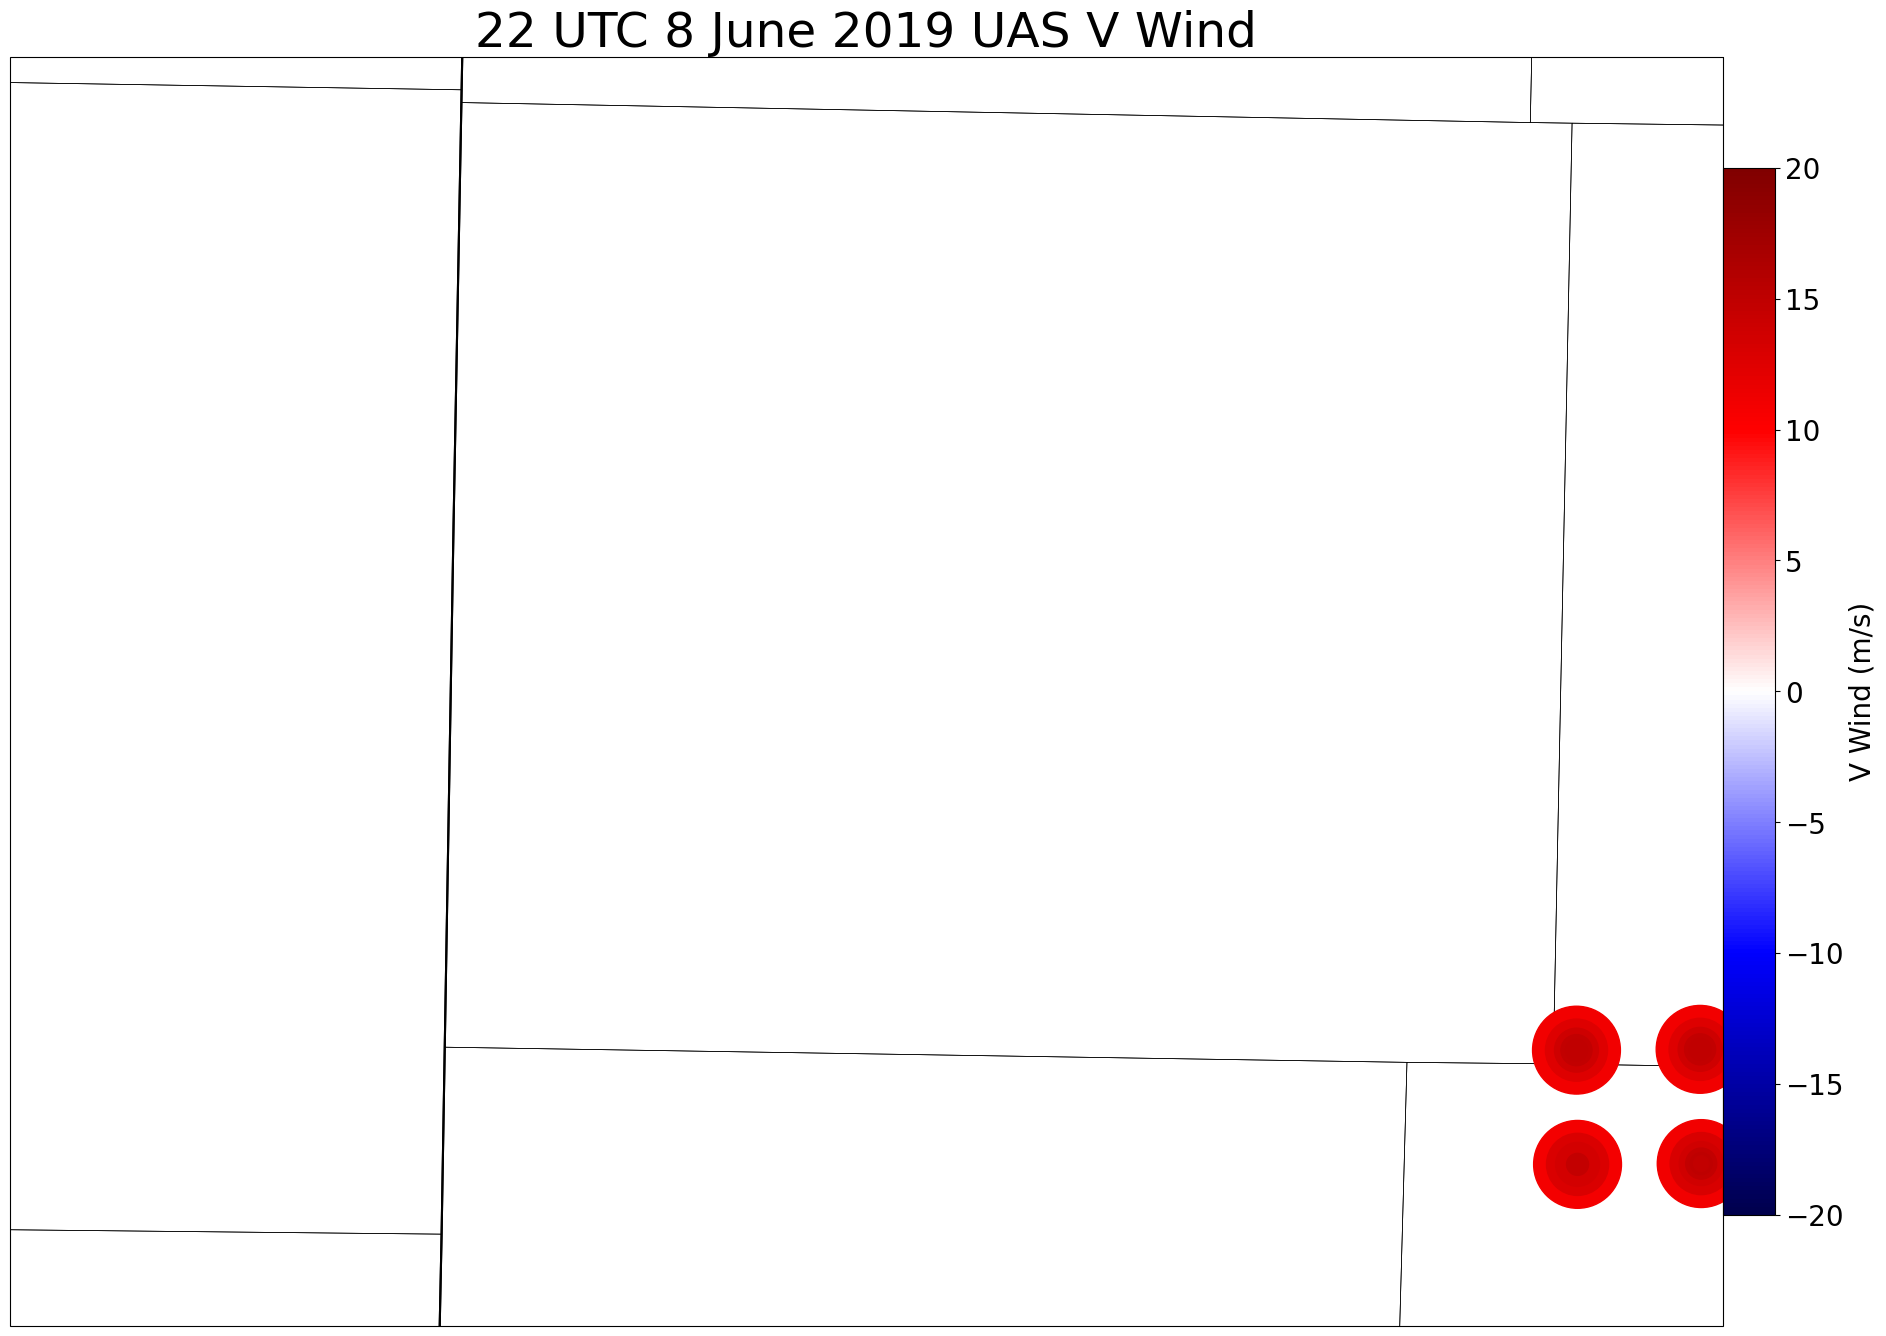

In [16]:
#Now let's plot a map with all of the supercell cases on it
lat = 39.3
lon = -101.8
cenlat1 = float(lat)
cenlon1 = float(lon)

#Let's set up the map projection!
# Set up our projection
crs = ccrs.LambertConformal(central_longitude=-100.0, central_latitude=45.0)
# Limit the extent of the map area, must convert to proper coords.
LL1 = crs.transform_point(cenlon1-0.5,cenlat1-0.3,ccrs.PlateCarree())
UR1 = crs.transform_point(cenlon1+0.5,cenlat1+0.3,ccrs.PlateCarree())

# LL1 = crs.transform_point(cenlon1-2.5,cenlat1-1.6,ccrs.PlateCarree())
# UR1 = crs.transform_point(cenlon1+1.5,cenlat1+1.6,ccrs.PlateCarree())

# Get data to plot state and province boundaries
states_provinces = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_1_states_provinces_lakes',
        scale='50m',
        facecolor='none')

#Make sure these shapefiles are in the same directory as the script
fname = 'C:/Users/matts/Documents/Python Scripts/SPORK Analysis Scripts/cb_2016_us_county_20m/cb_2016_us_county_20m.shp'
fname2 = 'C:/Users/matts/Documents/Python Scripts/SPORK Analysis Scripts/cb_2016_us_state_20m/cb_2016_us_state_20m.shp'
counties = ShapelyFeature(Reader(fname).geometries(),ccrs.PlateCarree(), facecolor = 'none', edgecolor = 'black')
states = ShapelyFeature(Reader(fname2).geometries(),ccrs.PlateCarree(), facecolor = 'none', edgecolor = 'black')

%matplotlib inline
#plt.style.use('bmh')
# Choose Forecast Hour (FH), FH = 0 is the first hour of dataset
# You can change and rerun this cell to get the different forecast hour
FH = 0
fig=plt.figure(1,figsize=(26.,17.))
ax = plt.subplot(111,projection=crs)
#   ax.set_extent([west long, east long, south lat, north lat])
ax.set_extent([LL1[0],UR1[0],LL1[1],UR1[1]],crs)
ax.coastlines('50m',edgecolor='black',linewidth=0.75)
#ax.add_feature(states_provinces,edgecolor='black',linewidth=0.5)
ax.add_feature(counties, edgecolor = 'black', linewidth = 0.5)
ax.add_feature(states, edgecolor = 'black', linewidth = 1.5)

#plt.scatter(Tmean_lon4, Tmean_lat4, c=Tmean_T4, transform=ccrs.PlateCarree())

size=8000
k2 = 1
for lev_g in range(len(U_levs3)):
    
    grid_x3 = np.asarray(lon_levs3[lev_g])
    grid_y3 = np.asarray(lat_levs3[lev_g])
    grid_U3 = np.asarray(V_levs3[lev_g])

    sc1 = plt.scatter(grid_x3[~np.isnan(grid_U3)], grid_y3[~np.isnan(grid_U3)], c=grid_U3[~np.isnan(grid_U3)], s=size, transform=ccrs.PlateCarree(), zorder=k2, vmin=-20, vmax=20, cmap=plt.cm.seismic)

    print(grid_U3[~np.isnan(grid_U3)])
    size=size/2
    k2=k2+1
    
    #plt.scatter(mean_lon3[lev_g], mean_lat3[lev_g], c=mean_alt3[lev_g], transform=ccrs.PlateCarree(), vmin=1200, vmax=1500, cmap=plt.cm.magma, zorder=20)

cg2 = plt.colorbar(sc1, shrink=0.80, pad=0.0)
cg2.ax.tick_params(labelsize=20)
cg2.set_label("V Wind (m/s)",size = 20)

plt.title('22 UTC 8 June 2019 UAS V Wind', size=35)

#plt.scatter(lon_all[2], lat_all[2], c=V_all[2] ,transform=ccrs.PlateCarree())

plt.savefig('UAS_GRID_22Zv.png')

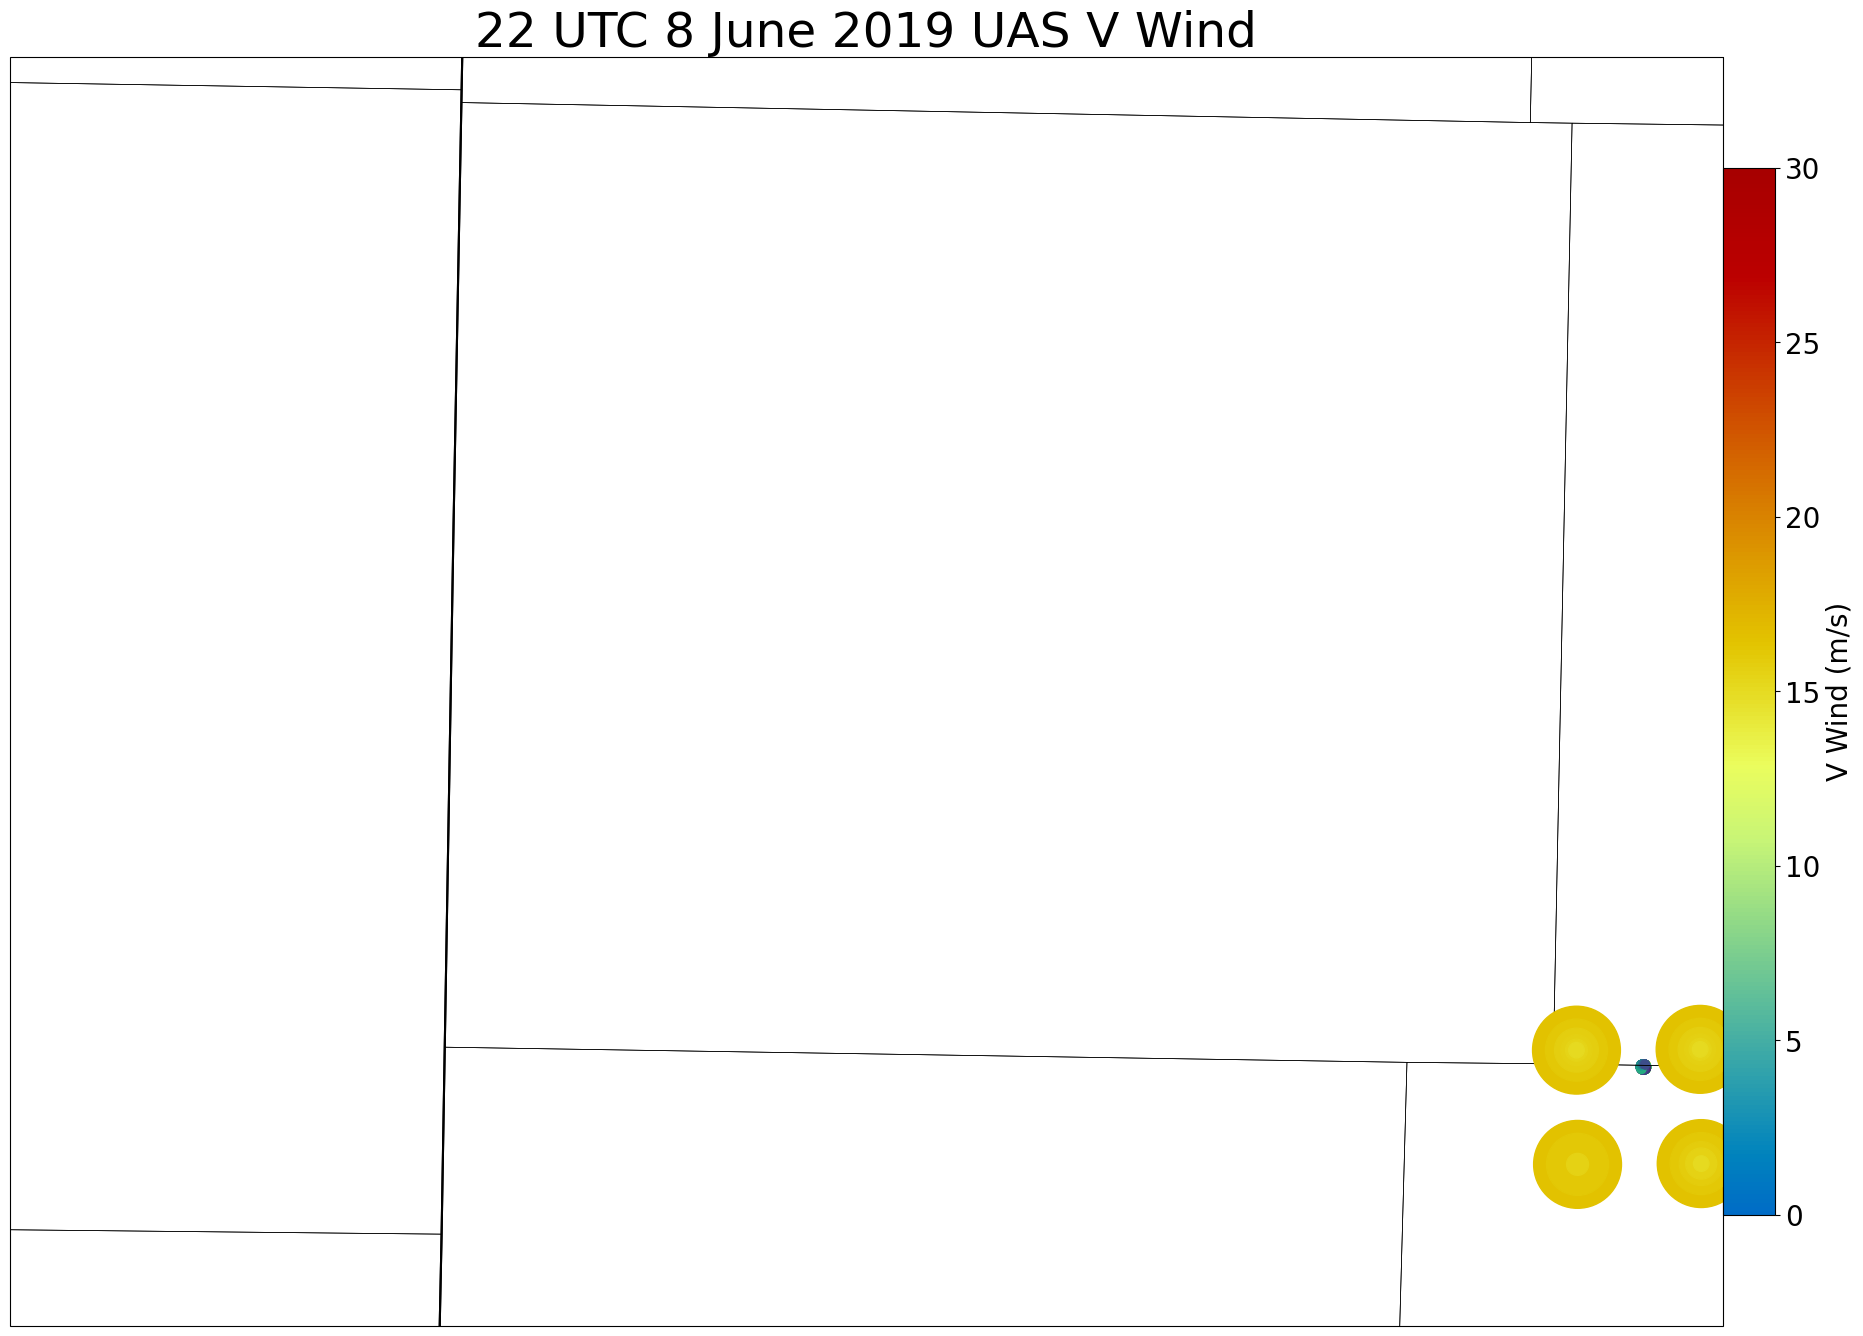

In [17]:
#Now let's plot a map with all of the supercell cases on it
lat = 39.3
lon = -101.8
cenlat1 = float(lat)
cenlon1 = float(lon)

#Convert the input lats and lons to an equal area projection
Albers_m = ccrs.AlbersEqualArea(central_longitude=-99.0, central_latitude=35.0, false_easting=0.0,
                                false_northing=0.0, standard_parallels=(20.0, 50.0), globe=None)

init_lons = np.asarray([-103.0, -100.0])
init_lats = np.asarray([38.0, 40.0])
dummy_latloni = Albers_m.transform_points(ccrs.PlateCarree(), init_lons, init_lats)
lon_dummyi = dummy_latloni[:,0]
lat_dummyi = dummy_latloni[:,1]

# grid_xt, grid_yt, grid_Tt = interpolate_to_grid(np.ndarray.flatten(savedlon[~np.isnan(savedT)]), np.ndarray.flatten(savedlat[~np.isnan(savedT)]), np.ndarray.flatten(savedT[~np.isnan(savedT)]), 
#                                                          hres=6000, interp_type='cressman', search_radius = 6000, minimum_neighbors=3,
#                                                          boundary_coords={'west':lon_dummyi[0], 'south':lat_dummyi[0], 'east':lon_dummyi[1], 'north':lat_dummyi[1]})


#Let's set up the map projection!
# Set up our projection
crs = ccrs.LambertConformal(central_longitude=-100.0, central_latitude=45.0)
# Limit the extent of the map area, must convert to proper coords.
LL1 = crs.transform_point(cenlon1-0.5,cenlat1-0.3,ccrs.PlateCarree())
UR1 = crs.transform_point(cenlon1+0.5,cenlat1+0.3,ccrs.PlateCarree())

# LL1 = crs.transform_point(cenlon1-2.5,cenlat1-1.6,ccrs.PlateCarree())
# UR1 = crs.transform_point(cenlon1+1.5,cenlat1+1.6,ccrs.PlateCarree())

# Get data to plot state and province boundaries
states_provinces = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_1_states_provinces_lakes',
        scale='50m',
        facecolor='none')

#Make sure these shapefiles are in the same directory as the script
fname = 'C:/Users/matts/Documents/Python Scripts/SPORK Analysis Scripts/cb_2016_us_county_20m/cb_2016_us_county_20m.shp'
fname2 = 'C:/Users/matts/Documents/Python Scripts/SPORK Analysis Scripts/cb_2016_us_state_20m/cb_2016_us_state_20m.shp'
counties = ShapelyFeature(Reader(fname).geometries(),ccrs.PlateCarree(), facecolor = 'none', edgecolor = 'black')
states = ShapelyFeature(Reader(fname2).geometries(),ccrs.PlateCarree(), facecolor = 'none', edgecolor = 'black')

%matplotlib inline
#plt.style.use('bmh')
# Choose Forecast Hour (FH), FH = 0 is the first hour of dataset
# You can change and rerun this cell to get the different forecast hour
FH = 0
fig=plt.figure(1,figsize=(26.,17.))
ax = plt.subplot(111,projection=crs)
#   ax.set_extent([west long, east long, south lat, north lat])
ax.set_extent([LL1[0],UR1[0],LL1[1],UR1[1]],crs)
ax.coastlines('50m',edgecolor='black',linewidth=0.75)
#ax.add_feature(states_provinces,edgecolor='black',linewidth=0.5)
ax.add_feature(counties, edgecolor = 'black', linewidth = 0.5)
ax.add_feature(states, edgecolor = 'black', linewidth = 1.5)

#plt.scatter(Tmean_lon4, Tmean_lat4, c=Tmean_T4, transform=ccrs.PlateCarree())

size=8000
k2 = 1
for lev_g in range(len(T_levs3)):
#for lev_g in [2]:
    
    grid_x3 = np.asarray(lon_levs3[lev_g])
    grid_y3 = np.asarray(lat_levs3[lev_g])
    grid_Td3 = np.asarray(Td_levs3[lev_g])

    sc1 = plt.scatter(grid_x3[~np.isnan(grid_Td3)], grid_y3[~np.isnan(grid_Td3)], c=grid_Td3[~np.isnan(grid_Td3)], s=size, transform=ccrs.PlateCarree(), zorder=k2, vmin=0, vmax=30, cmap=pyart.graph.cm_colorblind.HomeyerRainbow)

    #print(grid_T3[~np.isnan(grid_T3)])
    size=size/2
    k2=k2+1
    
    #plt.scatter(mean_lon3[lev_g], mean_lat3[lev_g], c=mean_alt3[lev_g], transform=ccrs.PlateCarree(), vmin=1200, vmax=1500, cmap=plt.cm.magma, zorder=20)

cg2 = plt.colorbar(sc1, shrink=0.80, pad=0.0)
cg2.ax.tick_params(labelsize=20)
cg2.set_label("V Wind (m/s)",size = 20)

plt.title('22 UTC 8 June 2019 UAS V Wind', size=35)

plt.scatter(np.ndarray.flatten(savedlon[~np.isnan(savedT)]), np.ndarray.flatten(savedlat[~np.isnan(savedT)]), c=np.ndarray.flatten(savedT[~np.isnan(savedT)]),transform=Albers_m)
#plt.scatter(grid_xt, grid_yt, c=grid_Tt,transform=Albers_m, zorder=10)

plt.scatter(lon_all[2], lat_all[2], c=T_all[2] ,transform=ccrs.PlateCarree())

#print(grid_Tt[~np.isnan(grid_Tt)])

plt.savefig('UAS_GRID_22ZT.png')

In [18]:
#Convert this all into a format that can be written out to an obs_seq file

L3_Tgood = []
L3_longood = []
L3_latgood = []
L3_altgood = []
L3_Ugood = []
L3_Ulongood = []
L3_Ulatgood = []
L3_Ualtgood = []
L3_Vgood = []
L3_Vlongood = []
L3_Vlatgood = []
L3_Valtgood = []
L3_Tdgood = []
L3_Tdlongood = []
L3_Tdlatgood = []
L3_Tdaltgood = []

for lev_g in range(len(T_levs3)):
    
    grid_x3 = np.asarray(lon_levs3[lev_g])
    grid_y3 = np.asarray(lat_levs3[lev_g])
    grid_T3 = np.asarray(T_levs3[lev_g])
    grid_alt3 = np.asarray(alt_levs3[lev_g])
    
    L3_Tgood.append(grid_T3[~np.isnan(grid_T3)])
    L3_longood.append(np.ndarray.flatten(grid_x3[~np.isnan(grid_T3)]))
    L3_latgood.append(np.ndarray.flatten(grid_y3[~np.isnan(grid_T3)]))
    L3_altgood.append(np.ndarray.flatten(grid_alt3[~np.isnan(grid_T3)]))
    
    grid_Ux3 = np.asarray(lon_levs3[lev_g])
    grid_Uy3 = np.asarray(lat_levs3[lev_g])
    grid_U3 = np.asarray(U_levs3[lev_g])
    grid_Ualt3 = np.asarray(alt_levs3[lev_g])
    
    L3_Ugood.append(grid_U3[~np.isnan(grid_U3)])
    L3_Ulongood.append(np.ndarray.flatten(grid_Ux3[~np.isnan(grid_U3)]))
    L3_Ulatgood.append(np.ndarray.flatten(grid_Uy3[~np.isnan(grid_U3)]))
    L3_Ualtgood.append(np.ndarray.flatten(grid_Ualt3[~np.isnan(grid_U3)]))
    
    grid_Vx3 = np.asarray(lon_levs3[lev_g])
    grid_Vy3 = np.asarray(lat_levs3[lev_g])
    grid_V3 = np.asarray(V_levs3[lev_g])
    grid_Valt3 = np.asarray(alt_levs3[lev_g])
    
    L3_Vgood.append(grid_V3[~np.isnan(grid_V3)])
    L3_Vlongood.append(np.ndarray.flatten(grid_Vx3[~np.isnan(grid_V3)]))
    L3_Vlatgood.append(np.ndarray.flatten(grid_Vy3[~np.isnan(grid_V3)]))
    L3_Valtgood.append(np.ndarray.flatten(grid_Valt3[~np.isnan(grid_V3)]))
    
    grid_Tdx3 = np.asarray(lon_levs3[lev_g])
    grid_Tdy3 = np.asarray(lat_levs3[lev_g])
    grid_Td3 = np.asarray(Td_levs3[lev_g])
    grid_Tdalt3 = np.asarray(alt_levs3[lev_g])
    
    L3_Tdgood.append(grid_Td3[~np.isnan(grid_Td3)])
    L3_Tdlongood.append(np.ndarray.flatten(grid_Tdx3[~np.isnan(grid_Td3)]))
    L3_Tdlatgood.append(np.ndarray.flatten(grid_Tdy3[~np.isnan(grid_Td3)]))
    L3_Tdaltgood.append(np.ndarray.flatten(grid_Tdalt3[~np.isnan(grid_Td3)]))
    
    
    


In [19]:
np.concatenate(L3_longood)

array([-101.37642662, -101.3033754 , -101.3780865 , -101.3049843 ,
       -101.37642662, -101.3033754 , -101.3780865 , -101.3049843 ,
       -101.37642662, -101.3033754 , -101.3780865 , -101.3049843 ,
       -101.3033754 , -101.3780865 , -101.3049843 , -101.37642662,
       -101.3033754 , -101.3780865 , -101.3049843 , -101.3033754 ,
       -101.3780865 , -101.3049843 ])

In [20]:
print(L3_Ulongood)
print(L3_longood)

[array([], dtype=float64), array([-101.37642662, -101.3033754 , -101.3780865 , -101.3049843 ]), array([-101.37642662, -101.3033754 , -101.3780865 , -101.3049843 ]), array([-101.37642662, -101.3033754 , -101.3780865 , -101.3049843 ]), array([-101.3033754, -101.3780865, -101.3049843]), array([-101.37642662, -101.3033754 , -101.3780865 , -101.3049843 ]), array([-101.3033754, -101.3780865, -101.3049843]), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64)]
[array([], dtype=float64), array([-101.37642662, -101.3033754 , -101.3780865 , -101.3049843 ]), array([-101.37642662, -101.3033754 , -101.3780865 , -101.3049843 ]), array([-101.37642662, -101.3033754 , -101.3780865 , -101.3049843 ]), array([-101.3033754, -101.3780865, -101.3049843]), array([-101.37642662, -101.3033754 , -101.3780865 , -101.3049843 ]), array([-101.3033754, -101.3780865, -101.3049843]), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64)]


In [21]:
L3_Tgoodf = np.concatenate(L3_Tgood)
L3_longoodf = np.concatenate(L3_longood)
L3_latgoodf = np.concatenate(L3_latgood)
L3_altgoodf = np.concatenate(L3_altgood)

L3_Ugoodf = np.concatenate(L3_Ugood)
L3_Ulongoodf = np.concatenate(L3_Ulongood)
L3_Ulatgoodf = np.concatenate(L3_Ulatgood)
L3_Ualtgoodf = np.concatenate(L3_Ualtgood)

L3_Vgoodf = np.concatenate(L3_Vgood)
L3_Vlongoodf = np.concatenate(L3_Vlongood)
L3_Vlatgoodf = np.concatenate(L3_Vlatgood)
L3_Valtgoodf = np.concatenate(L3_Valtgood)

L3_Tdgoodf = np.concatenate(L3_Tdgood)
L3_Tdlongoodf = np.concatenate(L3_Tdlongood)
L3_Tdlatgoodf = np.concatenate(L3_Tdlatgood)
L3_Tdaltgoodf = np.concatenate(L3_Tdaltgood)

In [22]:
print(L3_Ugoodf.shape, L3_Ulongoodf.shape, L3_Ulatgoodf.shape)

(22,) (22,) (22,)


In [23]:
#Convert lons and lats to radians
R3_longoodf = np.radians(L3_longoodf)
R3_latgoodf = np.radians(L3_latgoodf)

R3_longoodf = np.where(R3_longoodf > 0.0, R3_longoodf, R3_longoodf+(2.0*np.pi))

R3_Ulongoodf = np.radians(L3_Ulongoodf)
R3_Ulatgoodf = np.radians(L3_Ulatgoodf)

R3_Ulongoodf = np.where(R3_Ulongoodf > 0.0, R3_Ulongoodf, R3_Ulongoodf+(2.0*np.pi))

R3_Vlongoodf = np.radians(L3_Vlongoodf)
R3_Vlatgoodf = np.radians(L3_Vlatgoodf)

R3_Vlongoodf = np.where(R3_Vlongoodf > 0.0, R3_Vlongoodf, R3_Vlongoodf+(2.0*np.pi))

R3_Tdlongoodf = np.radians(L3_Tdlongoodf)
R3_Tdlatgoodf = np.radians(L3_Tdlatgoodf)

R3_Tdlongoodf = np.where(R3_Tdlongoodf > 0.0, R3_Tdlongoodf, R3_Tdlongoodf+(2.0*np.pi))

In [24]:
#Set up some times
dt_time3  = dt_start - datetime(1601,1,1,0,0,0)
dt_seconds3 = dt_time3.seconds
dt_days3 = dt_time3.days
#And obs error varince for T
#T and wind variances from Jensen et al. (2022), specific humidity variance same as mobile mesonets. 
#Could use the 3% RH value from Jensen, but we'd need to assimilate RH instead of specific humidity.
oerror_T = 1.0
oerror_U = 1.0
oerror_V = 1.0
oerror_Td = 1.0

#Substitute the ACARS observation errors to deal with filter divergence
#U and V are default ACARS, T and Td are same as METAR defaults

# oerror_T = 2.5
# oerror_U = 2.5
# oerror_V = 2.5
# oerror_Td = 2.5

print(dt_time3.seconds)
print(dt_time3.days)

3600
152830


In [31]:
time_bracket = dt_start

#Set up some code to write out an obs_seq file
#Code adapted from PyOpaws's obs_seq writing code
#Set obs types
akind1 = 118
akind2 = 116
akind3 = 117
akind4 = 74

#nobs=2
ob_ind = 1
data = L3_Tgoodf
data = np.asarray(data)
data = data + 273.15
data2 = L3_Ugoodf
data2 = np.asarray(data2)
data3 = L3_Vgoodf
data3 = np.asarray(data3)
data4 = L3_Tdgoodf
data4 = np.asarray(data4)
data4 = data4 + 273.15

kind1arr = np.full(len(data), akind1)
kind2arr = np.full(len(data2), akind2)
kind3arr = np.full(len(data3), akind3)
kind4arr = np.full(len(data4), akind4)
oerrarr1 = np.full(len(data), oerror_T)
oerrarr2 = np.full(len(data2), oerror_U)
oerrarr3 = np.full(len(data3), oerror_V)
oerrarr4 = np.full(len(data4), oerror_Td)

#Concatenate arrays and make static arrays
data_all = np.concatenate([data, data2, data3, data4])
lons_all = np.concatenate([R3_longoodf, R3_Ulongoodf, R3_Vlongoodf, R3_Tdlongoodf])
lats_all = np.concatenate([R3_latgoodf, R3_Ulatgoodf, R3_Vlatgoodf, R3_Tdlatgoodf])
alts_all = np.concatenate([L3_altgoodf, L3_Ualtgoodf, L3_Valtgoodf, L3_Tdaltgoodf])
kinds_all = np.concatenate([kind1arr, kind2arr, kind3arr, kind4arr])
errs_all = np.concatenate([oerrarr1, oerrarr2, oerrarr3, oerrarr4])

nobs = len(data_all)
truth = 1.0

DARTname1 = 'UAS_TEMPERATURE'
DARTname2 = 'UAS_U_WIND_COMPONENT'
DARTname3 = 'UAS_V_WIND_COMPONENT'
DARTname4 = 'UAS_DEWPOINT'

#filename = 'obs_TORUS_UAS2022'+str(time_bracket.hour)+str(time_bracket.minute)
filename = 'SEDEWobs_TORUS_UASDEF2022'+str(time_bracket.hour)+str(time_bracket.minute)

fi = open(filename, "w")

fi.write(" obs_sequence\n")
fi.write("obs_kind_definitions\n")

if len(data) > 0:

    fi.write("    %d \n" %(4))
    fi.write("    %d          %s   \n" %(akind1, DARTname1))
    fi.write("    %d          %s   \n" %(akind2, DARTname2))
    fi.write("    %d          %s   \n" %(akind3, DARTname3))
    fi.write("    %d          %s   \n" %(akind4, DARTname4))

else:
    
    fi.write("    %d \n" %(2))
    fi.write("    %d          %s   \n" %(akind2, DARTname2))
    fi.write("    %d          %s   \n" %(akind3, DARTname3))
    
fi.write("  num_copies:            %d  num_qc:            %d\n" % (1, 1))
fi.write(" num_obs:       %d  max_num_obs:       %d\n" % (nobs, nobs) )

fi.write("MADIS observation\n")
fi.write("Data QC\n")

fi.write("  first:            %d  last:       %d\n" % (1, nobs) )

for q in range(nobs):

    fi.write(" OBS            %d\n" % (q+1) )
    fi.write("   %20.14f\n" % data_all[q]  )
    fi.write("   %20.14f\n" % truth )

    if q+1 == 1: 
      fi.write(" %d %d %d\n" % (-1, q+2, -1) ) # First obs.
    elif q+1 == nobs:
      fi.write(" %d %d %d\n" % (q, -1, -1) ) # Last obs.
    else:
      fi.write(" %d %d %d\n" % (q, q+2, -1) ) 

    fi.write("obdef\n")
    fi.write("loc3d\n")

    fi.write("    %20.14f          %20.14f          %20.14f     %d\n" % 
                      (lons_all[q], lats_all[q], alts_all[q], 3))
    fi.write("kind\n")
    
    fi.write("     %d     \n" % kinds_all[q] )
    
    fi.write("    %d          %d     \n" % (dt_seconds3, dt_days3) )
    
    fi.write("    %20.14f  \n" % errs_all[q]**2 )

In [26]:
print('done')

done


In [27]:
print(alts_all)

[ 1100.59472166  1100.48121128  1100.11700835  1100.18494955  1167.77948916
  1173.25918005  1169.9650754   1169.91199667  1230.30166972  1260.07465661
  1264.00242969  1264.8558905   1359.39478264  1360.88806733  1360.42632633
  1472.68644329  1455.42074093  1455.58367868  1454.83849905  1544.60999718
  1546.0382157   1546.46270397  1100.59472166  1100.48121128  1100.11700835
  1100.18494955  1167.77948916  1173.25918005  1169.9650754   1169.91199667
  1230.30166972  1260.07465661  1264.00242969  1264.8558905   1359.39478264
  1360.88806733  1360.42632633  1472.68644329  1455.42074093  1455.58367868
  1454.83849905  1544.60999718  1546.0382157   1546.46270397  1100.59472166
  1100.48121128  1100.11700835  1100.18494955  1167.77948916  1173.25918005
  1169.9650754   1169.91199667  1230.30166972  1260.07465661  1264.00242969
  1264.8558905   1359.39478264  1360.88806733  1360.42632633  1472.68644329
  1455.42074093  1455.58367868  1454.83849905  1544.60999718  1546.0382157
  1546.462703

In [28]:
print(p_RF1[2])
print(p_NI2[2])

[]
[]


In [29]:
print(T_levs3[6][~np.isnan(Td_levs3[6])])

[ 24.30689793  24.46166067  24.45082724]


In [30]:
print(data4)

[ 289.66677908  289.58354619  289.5591569   289.55637248  289.28863053
  289.24050718  289.24606865  289.24645928  289.20491971  289.05206896
  288.94946835  288.94797189  288.71417224  288.73988527  288.73905099
  288.63643078  288.62135473  288.60035447  288.60111639  288.26443414
  288.23864492  288.2386266 ]
